# Análisis de Resultados — IaC-Eval + SecLLM

Auditoría de seguridad de Terraform generado por LLMs. Este notebook carga los
resultados crudos de los dos experimentos y reproduce las métricas y figuras de
los reportes (`REPORTE_COMPARATIVO.md` y `REPORT_v2.md`).

**Definiciones de métricas** (idénticas a `scripts/generate_report_v2.py`):

| Métrica | Definición |
|---------|------------|
| **Fc** (Functional correctness) | `1` si OPA devuelve `Success`, `0` en otro caso |
| **Sc** (Smell Count) | nº de detecciones de SecLLM por script (excluye `none`) |
| **Sp** (Smell Prevalence) | `1` si el script no tiene smells, `0` si tiene ≥1 |

**Experimentos**
- **V1** (`outputs/`): un directorio por modelo. Baseline exploratorio.
- **V2** (`outputs_v2/`): un directorio por modelo × condición de prompt **P0** (neutral) / **P1** (security-oriented). Muestreo estratificado (40 escenarios/modelo).


In [1]:
import json
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize": (9, 5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)


def find_integration_dir(start: Path) -> Path:
    # Localiza el directorio que contiene outputs/ y outputs_v2/.
    for base in [start, *start.parents]:
        if (base / "outputs").is_dir() and (base / "outputs_v2").is_dir():
            return base
        if (base / "integration" / "outputs_v2").is_dir():
            return base / "integration"
    raise FileNotFoundError("No se encontró el directorio 'integration' con outputs/ y outputs_v2/.")


INTEGRATION = find_integration_dir(Path.cwd())
OUT_V1 = INTEGRATION / "outputs"
OUT_V2 = INTEGRATION / "outputs_v2"
print("Directorio de integración:", INTEGRATION)
print("V1:", OUT_V1.exists(), "| V2:", OUT_V2.exists())

Directorio de integración: c:\Users\annab_kh6mf3w\Documents\secllm-terraform-integration\research_iac\integration
V1: True | V2: True


## 1. Carga de datos

Reutilizamos la misma lógica de `load_model_condition` del generador de reportes
para garantizar que las métricas coincidan exactamente.

In [2]:
def load_condition(cond_dir: Path) -> dict:
    # Carga iac_eval + secllm de un directorio y devuelve {file -> métricas}.
    func_path = cond_dir / "iac_eval_results.json"
    audit_path = cond_dir / "secllm_results.json"
    if not func_path.exists():
        return {}
    func_data = json.loads(func_path.read_text(encoding="utf-8"))

    smells_by_file = defaultdict(list)
    if audit_path.exists():
        for rec in json.loads(audit_path.read_text(encoding="utf-8")):
            smell = rec.get("SMELL", "none")
            if smell != "none":
                smells_by_file[rec["PATH"]].append(smell)

    records = {}
    for r in func_data:
        fname = r["file"]
        fc = 1 if r.get("opa_evaluation_result") == "Success" else 0
        plan_ok = bool(r.get("terraform_plan_success"))
        smells = smells_by_file.get(fname, [])
        records[fname] = {
            "file": fname,
            "plan_success": plan_ok,
            "Fc": fc,
            "Sc": len(smells),
            "Sp": 1 if len(smells) == 0 else 0,
            "smells": smells,
        }
    return records


def discover(base: Path) -> list[str]:
    return sorted(
        d.name for d in base.iterdir()
        if d.is_dir() and not d.name.startswith(".")
    )


# ---- V2: modelo × condición (P0/P1) ----
rows_v2 = []
for model in discover(OUT_V2):
    for cond in ("P0", "P1"):
        for rec in load_condition(OUT_V2 / model / cond).values():
            rows_v2.append({"model": model, "condition": cond, **rec})

df_v2 = pd.DataFrame(rows_v2)

# ---- V1: solo modelo ----
rows_v1 = []
for model in discover(OUT_V1):
    for rec in load_condition(OUT_V1 / model).values():
        rows_v1.append({"model": model, **rec})
df_v1 = pd.DataFrame(rows_v1)

print(f"V2: {len(df_v2)} scripts | modelos: {sorted(df_v2['model'].unique())}")
print(f"V1: {len(df_v1)} scripts | modelos: {sorted(df_v1['model'].unique())}")
df_v2.head()

V2: 320 scripts | modelos: ['codegemma_7b', 'codellama_7b', 'granite-code_8b', 'llama3_1_8b']
V1: 140 scripts | modelos: ['deepseek-r1_32b', 'devstral-small-2_latest', 'glm-4_7-flash_q8_0', 'llama3_1_8b', 'qwen2_5-coder_32b', 'qwen2_5-coder_7b']


,model,condition,file,plan_success,Fc,Sc,Sp,smells
0,codegemma_7b,P0,question_0000.tf,False,0,1,0,[unrestricted_ip_address]
1,codegemma_7b,P0,question_0003.tf,False,0,0,1,[]
2,codegemma_7b,P0,question_0005.tf,False,0,0,1,[]
3,codegemma_7b,P0,question_0012.tf,False,0,0,1,[]
4,codegemma_7b,P0,question_0018.tf,False,0,3,0,"[hard_coded_secret, admin_by_default, suspicio..."


## 2. Experimento V1 — Baseline

### 2.1 Evaluación funcional (IaC-Eval)
Compilación (`terraform plan`) y cumplimiento de política (OPA).

In [3]:
func_v1 = (df_v1.groupby("model")
           .agg(archivos=("file", "count"),
                compila=("plan_success", "sum"),
                pasa_opa=("Fc", "sum"))
           .reset_index())
func_v1["% compila"] = (100 * func_v1["compila"] / func_v1["archivos"]).round(1)
func_v1["% OPA"] = (100 * func_v1["pasa_opa"] / func_v1["archivos"]).round(1)
func_v1

,model,archivos,compila,pasa_opa,% compila,% OPA
0,deepseek-r1_32b,5,0,0,0.0,0.0
1,devstral-small-2_latest,45,18,4,40.0,8.9
2,glm-4_7-flash_q8_0,5,2,0,40.0,0.0
3,llama3_1_8b,40,8,1,20.0,2.5
4,qwen2_5-coder_32b,5,2,0,40.0,0.0
5,qwen2_5-coder_7b,40,5,0,12.5,0.0


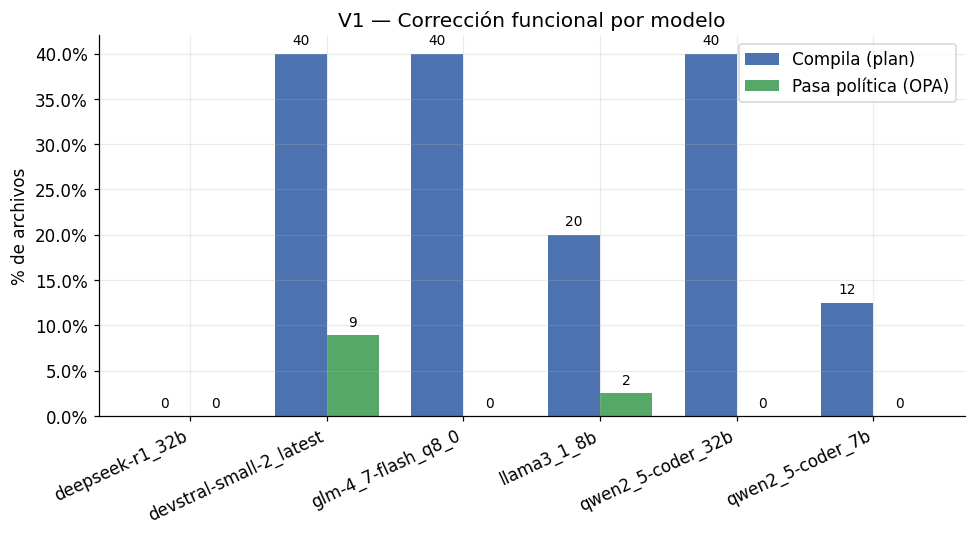

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(func_v1))
w = 0.38
ax.bar(x - w/2, func_v1["% compila"], w, label="Compila (plan)", color=PALETTE[0])
ax.bar(x + w/2, func_v1["% OPA"], w, label="Pasa política (OPA)", color=PALETTE[2])
ax.set_xticks(x)
ax.set_xticklabels(func_v1["model"], rotation=25, ha="right")
ax.set_ylabel("% de archivos")
ax.set_title("V1 — Corrección funcional por modelo")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend()
for i, r in func_v1.iterrows():
    ax.text(i - w/2, r["% compila"] + 1, f'{r["% compila"]:.0f}', ha="center", fontsize=9)
    ax.text(i + w/2, r["% OPA"] + 1, f'{r["% OPA"]:.0f}', ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### 2.2 Auto-auditoría de seguridad (SecLLM)
¿Cuántas vulnerabilidades detecta cada modelo en el código que él mismo generó,
y de qué tipo?

In [5]:
sec_rows = []
for _, r in df_v1.iterrows():
    for s in r["smells"]:
        sec_rows.append({"model": r["model"], "smell": s})
sec_v1 = pd.DataFrame(sec_rows)

pivot_v1 = (sec_v1.pivot_table(index="model", columns="smell",
                               aggfunc="size", fill_value=0)
            if not sec_v1.empty else pd.DataFrame())
audit_v1 = df_v1.groupby("model").agg(auditados=("file", "count"),
                                      vulnerabilidades=("Sc", "sum")).reset_index()
display(audit_v1)
pivot_v1

,model,auditados,vulnerabilidades
0,deepseek-r1_32b,5,4
1,devstral-small-2_latest,45,47
2,glm-4_7-flash_q8_0,5,0
3,llama3_1_8b,40,87
4,qwen2_5-coder_32b,5,9
5,qwen2_5-coder_7b,40,80


smell,admin_by_default,empty_password,hard_coded_secret,no_integrity_check,suspicious_comment,unrestricted_ip_address,use_of_http_without_tls,use_of_weak_cryptography
model,,,,,,,,
deepseek-r1_32b,0,0,0,0,2,2,0,0
devstral-small-2_latest,16,0,15,1,9,2,4,0
llama3_1_8b,25,16,22,12,1,3,2,6
qwen2_5-coder_32b,4,0,4,0,0,1,0,0
qwen2_5-coder_7b,20,0,20,0,20,14,6,0


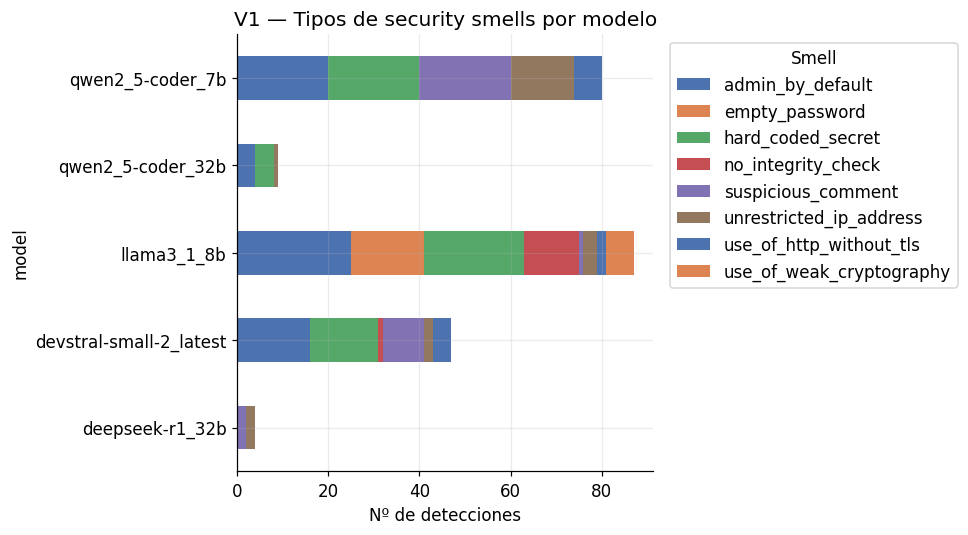

In [6]:
if not pivot_v1.empty:
    ax = pivot_v1.plot(kind="barh", stacked=True, figsize=(9, 5),
                       color=PALETTE[:pivot_v1.shape[1]])
    ax.set_xlabel("Nº de detecciones")
    ax.set_title("V1 — Tipos de security smells por modelo")
    ax.legend(title="Smell", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("Sin smells registrados en V1.")

## 3. Experimento V2 — Prompting P0 vs P1 (muestreo estratificado)

Todos los modelos comparten los mismos 40 escenarios por condición.
Cargamos las estadísticas ya calculadas (`stats_*.json`) para los tests de
hipótesis y reproducimos las figuras a partir de los datos crudos.

In [7]:
def load_stats(name):
    p = OUT_V2 / name
    if not p.exists():
        return None
    # NaN aparece sin comillas en los JSON generados
    return json.loads(p.read_text(encoding="utf-8").replace("NaN", "null"))

stats_rq1 = load_stats("stats_rq1.json")
stats_rq2 = load_stats("stats_rq2.json")
stats_models = load_stats("stats_models.json")
stats_rq3 = load_stats("stats_rq3.json")
stats_fail = load_stats("stats_failure_modes.json")

summary_v2 = (df_v2.groupby(["model", "condition"])
              .agg(n=("file", "count"),
                   Fc_rate=("Fc", "mean"),
                   Sc_mean=("Sc", "mean"),
                   Sp_rate=("Sp", "mean"))
              .round(3).reset_index())
summary_v2

,model,condition,n,Fc_rate,Sc_mean,Sp_rate
0,codegemma_7b,P0,40,0.025,0.675,0.700
1,codegemma_7b,P1,40,0.025,0.250,0.775
2,codellama_7b,P0,40,0.100,0.925,0.700
3,codellama_7b,P1,40,0.150,0.725,0.575
4,granite-code_8b,P0,40,0.025,0.600,0.725
5,granite-code_8b,P1,40,0.025,0.425,0.775
6,llama3_1_8b,P0,40,0.000,1.750,0.575
7,llama3_1_8b,P1,40,0.000,0.700,0.550


### 3.1 RQ1 — Correlación entre corrección funcional (Fc) y smells (Sc), condición P0
Spearman ρ / Kendall τ, con corrección Holm-Bonferroni.

,muestra,N,Spearman ρ,p (raw),p (Holm),Kendall τ
0,codegemma_7b,40,0.3344,0.0349,0.3494,0.3183
1,codellama_7b,40,-0.0268,0.8698,1.0000,-0.0253
2,granite-code_8b,40,-0.0971,0.5511,1.0000,-0.0926
3,llama3_1_8b,40,NaN,NaN,1.0000,NaN
4,Pooled,160,0.0291,0.7145,1.0000,0.0273


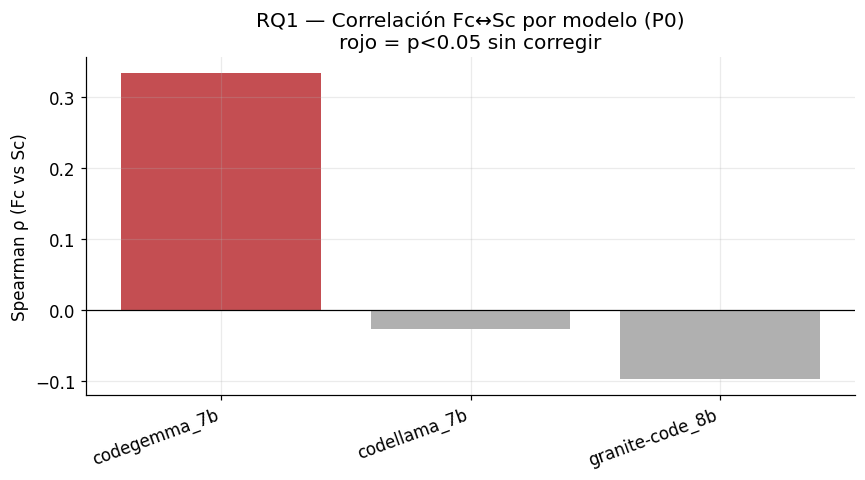

In [8]:
rq1_rows = []
for slug, r in stats_rq1.items():
    rq1_rows.append({
        "muestra": "Pooled" if slug == "_pooled" else slug,
        "N": r["n"],
        "Spearman ρ": r["spearman_rho"],
        "p (raw)": r["spearman_p"],
        "p (Holm)": r["spearman_p_adj_holm"],
        "Kendall τ": r["kendall_tau"],
    })
rq1_df = pd.DataFrame(rq1_rows)
display(rq1_df)

# Spearman ρ por modelo (excluye pooled y NaN)
plot_rq1 = rq1_df[(rq1_df["muestra"] != "Pooled") & rq1_df["Spearman ρ"].notna()]
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#C44E52" if p < 0.05 else "#B0B0B0" for p in plot_rq1["p (raw)"]]
ax.bar(plot_rq1["muestra"], plot_rq1["Spearman ρ"], color=colors)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("Spearman ρ (Fc vs Sc)")
ax.set_title("RQ1 — Correlación Fc↔Sc por modelo (P0)\nrojo = p<0.05 sin corregir")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### 3.2 RQ2 — Efecto del prompt security-oriented (P0 → P1) sobre Sc
Wilcoxon signed-rank pareado. Un descenso de Sc̄ indica menos smells con P1.

,modelo,N,Sc̄ P0,Sc̄ P1,p(Sc),p_Holm(Sc),r(Sc),Fc P0,Fc P1
0,codegemma_7b,40,0.675,0.250,0.0457,0.1371,0.2095,0.025,0.025
1,codellama_7b,40,0.925,0.725,0.4450,0.8594,0.3857,0.100,0.150
2,granite-code_8b,40,0.600,0.425,0.4297,0.8594,0.3455,0.025,0.025
3,llama3_1_8b,40,1.750,0.700,0.0229,0.0917,0.2253,0.000,0.000


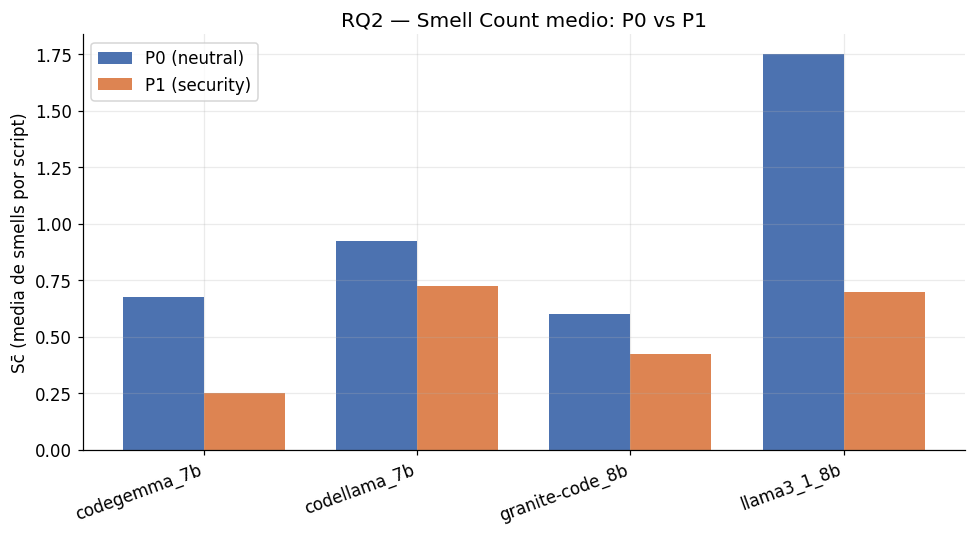

In [9]:
rq2_rows = []
for slug, r in stats_rq2.items():
    if "note" in r and "Sc_mean_P0" not in r:
        continue
    rq2_rows.append({
        "modelo": slug,
        "N": r.get("n_paired"),
        "Sc̄ P0": r.get("Sc_mean_P0"),
        "Sc̄ P1": r.get("Sc_mean_P1"),
        "p(Sc)": r.get("Sc_p"),
        "p_Holm(Sc)": r.get("Sc_p_adj_holm"),
        "r(Sc)": r.get("Sc_r"),
        "Fc P0": r.get("Fc_rate_P0"),
        "Fc P1": r.get("Fc_rate_P1"),
    })
rq2_df = pd.DataFrame(rq2_rows)
display(rq2_df)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(rq2_df))
w = 0.38
ax.bar(x - w/2, rq2_df["Sc̄ P0"], w, label="P0 (neutral)", color=PALETTE[0])
ax.bar(x + w/2, rq2_df["Sc̄ P1"], w, label="P1 (security)", color=PALETTE[1])
ax.set_xticks(x); ax.set_xticklabels(rq2_df["modelo"], rotation=20, ha="right")
ax.set_ylabel("Sc̄ (media de smells por script)")
ax.set_title("RQ2 — Smell Count medio: P0 vs P1")
ax.legend()
plt.tight_layout()
plt.show()

### 3.3 Comparación exploratoria entre modelos (Sc, condición P0)
Kruskal-Wallis global + Mann-Whitney pareado (BH-FDR). Distribución de Sc por modelo.

Kruskal-Wallis: H=4.1436, p=0.2464, η²=0.0073 (k=4, N=160)


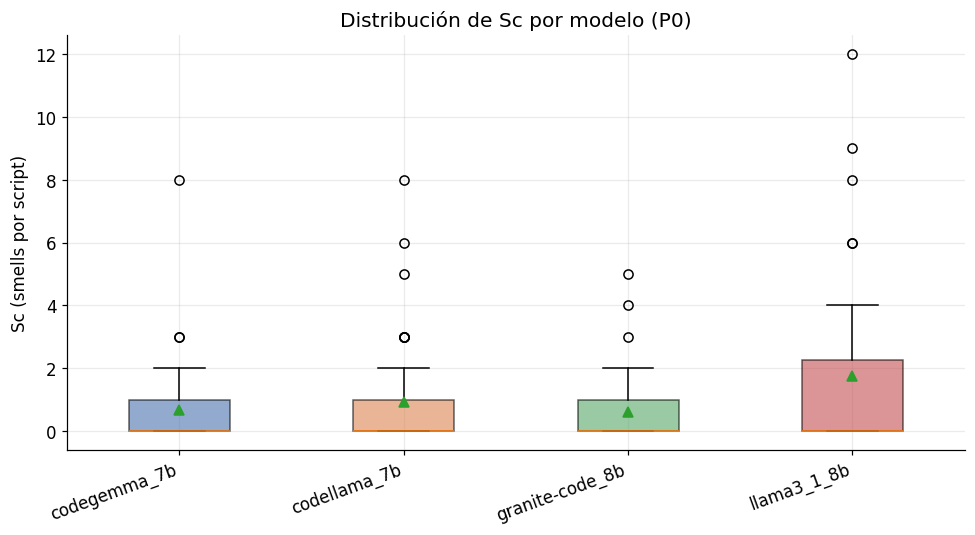

In [10]:
kw = stats_models["kruskal_wallis"]
print(f"Kruskal-Wallis: H={kw['H']}, p={kw['p']}, η²={kw['eta_squared']} "
      f"(k={kw['k']}, N={kw['n_total']})")

p0 = df_v2[df_v2["condition"] == "P0"]
models_p0 = sorted(p0["model"].unique())
data = [p0[p0["model"] == m]["Sc"].values for m in models_p0]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(data, labels=models_p0, patch_artist=True, showmeans=True)
for patch, c in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.set_ylabel("Sc (smells por script)")
ax.set_title("Distribución de Sc por modelo (P0)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### 3.4 RQ3 — Security smells en scripts funcionalmente correctos (Fc=1, P0)
¿Qué vulnerabilidades persisten incluso en código que compila y pasa OPA?

Scripts con Fc=1: 6 · Detecciones totales: 11


,smell,detecciones
0,admin_by_default,9
1,hard_coded_secret,1
2,suspicious_comment,1


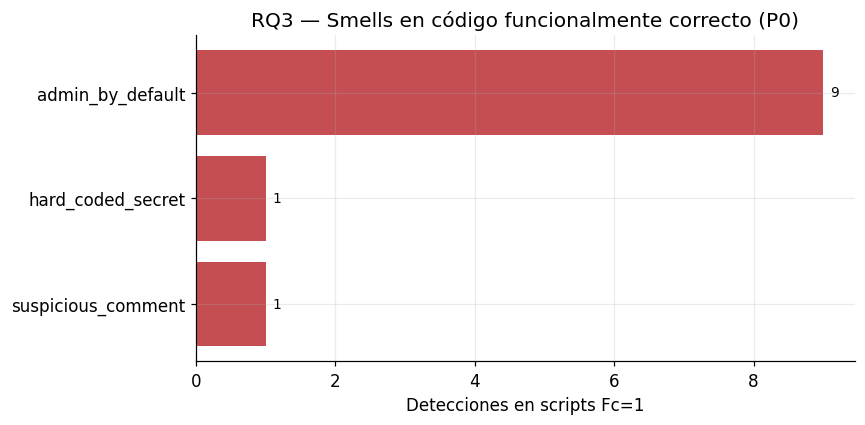

In [11]:
dist = stats_rq3["smell_distribution_fc1"]
print(f"Scripts con Fc=1: {stats_rq3['total_fc1_scripts']} · "
      f"Detecciones totales: {stats_rq3['total_smell_detections_in_fc1']}")
rq3_df = pd.DataFrame(sorted(dist.items(), key=lambda x: -x[1]),
                      columns=["smell", "detecciones"])
display(rq3_df)

if not rq3_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(rq3_df["smell"], rq3_df["detecciones"], color=PALETTE[3])
    ax.invert_yaxis()
    ax.set_xlabel("Detecciones en scripts Fc=1")
    ax.set_title("RQ3 — Smells en código funcionalmente correcto (P0)")
    for i, v in enumerate(rq3_df["detecciones"]):
        ax.text(v + 0.1, i, str(v), va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

## 4. Resumen de hallazgos

- **V1** deja ver una gran variabilidad de compilación entre modelos y que las
  auto-auditorías dominan en `admin_by_default` y `hard_coded_secret`.
- **RQ1**: no hay correlación robusta entre Fc y Sc tras la corrección múltiple
  (Pooled ρ≈0.03, p_Holm=1.0) → *corrección funcional y seguridad son ejes
  independientes*.
- **RQ2**: P1 (security-oriented) reduce la media de smells en varios modelos,
  pero ninguna diferencia sobrevive a Holm-Bonferroni con N=40.
- **RQ3**: incluso en código con Fc=1 persisten smells (`admin_by_default`
  domina) → *pasar OPA no garantiza ausencia de malas prácticas de seguridad*.

> Las tablas y figuras se recalculan al ejecutar el notebook; los tests de
> hipótesis provienen de `stats_*.json` generados por `scripts/generate_report_v2.py`.
